## 1. Introduction to the Butler for the DP1 ComCam--VISTA ECDFS data

This notebook provides a first inspection of the lsst-ir-fusion-dp1 Butler repository on the UK RSP. The repository contains DP1 ECDFS products generated with the ComCam--VISTA fusion pipeline.

The notebook introduces the basic Butler access pattern, lists the available collections and dataset types, identifies the skymap used by the repository, and checks which coadd images and catalogue products are available. It is intended as a starting point for exploring the DP1 data products.


### 1.1 Imports

We start with standard scientific Python packages, together with the LSST Butler, geometry tools, and display tools.

In [1]:
# General scientific Python packages
import itertools
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Butler and LSST geometry/display packages
import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay


### 1.2 Basic configuration

Set the Butler repository label in the `REPO` variable below.

The default sky position below is in ECDFS/CDFS.  You can replace it with the position of one of your science targets.


In [2]:
# Butler repository label on the UK RSP.
# Use the repository name that contains the DP1 ComCam--VISTA products.
REPO = "lsst-ir-fusion-dp1"

# Example ECDFS/CDFS sky position, in degrees.
# Replace these coordinates with a specific science target when needed.
TARGET_NAME = "ECDFS example position"
TARGET_RA_DEG = 53.254138
TARGET_DEC_DEG = -28.127224

# Preferred skymap for the DP1 ComCam--VISTA products.
# If this skymap is not present, the notebook will fall back to the first available skymap.
PREFERRED_SKYMAP = "lsst_cells_v1"

# Preferred band for the example image display.
# The code will try the first available band in this order.
# For VISTA products this may be "K", "Ks", "H", "J", "Y", or "Z".
# For ComCam/optical products this may be "u", "g", "r", "i", "z", or "y".
PREFERRED_BANDS = ["K", "Ks", "H", "J", "Y", "Z", "i", "r", "g", "z", "y", "u"]

# Collection expression to search.
# Leave this as Ellipsis (...) to search all collections in the repository.
# If the search is too slow, set this to a list of collection names after inspecting cell 1.4.
SEARCH_COLLECTIONS = ...

# Optional manual data ID override.
# Leave as None normally.  Use this only if you already know the exact tract/patch.
# Example:
# DATA_ID_OVERRIDE = {"skymap": "lsst_cells_v1", "tract": 5063, "patch": 14}
DATA_ID_OVERRIDE = None


### 1.3 Initialize the Butler

The Butler gives access to the datasets stored in the repository, while the registry lets us query collections, dataset types, dimensions, and data IDs.

In [3]:
butler = dafButler.Butler(REPO)
registry = butler.registry

print("Opened Butler repository:", REPO)

Opened Butler repository: lsst-ir-fusion-dp1


### 1.4 Inspect available collections

A Butler collection is a named grouping of datasets.  The DP1 repository can contain several collections, including ComCam optical products, VISTA near-infrared products, coadd outputs, and catalogue outputs.

This cell only prints names.  It does not assume any particular old XMM collection name.

In [4]:
all_collections = sorted(registry.queryCollections())

print(f"Number of collections found: {len(all_collections)}")
print()
print("Available collections:")
for collection in all_collections:
    print(" ", collection)

print()
if SEARCH_COLLECTIONS is ...:
    print("Current search setting: all collections")
else:
    print("Current search setting:")
    for collection in SEARCH_COLLECTIONS:
        print(" ", collection)

Number of collections found: 4

Available collections:
  skymaps
  u/ir-sare1/DRP/videoCoaddDetect
  u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z

Current search setting: all collections


### 1.5 Inspect dataset types

We first build `dataset_type_names`, then print dataset types that look relevant to coadds and catalogues.

In [5]:
all_dataset_types = sorted(registry.queryDatasetTypes(), key=lambda dt: dt.name)
dataset_type_names = [dt.name for dt in all_dataset_types]

print(f"Number of dataset types found: {len(dataset_type_names)}")
print()

def show_dataset_types_matching(words, max_rows=200):
    """Print dataset types whose names contain at least one of the given words."""
    words = tuple(word.lower() for word in words)
    matches = []
    for dt in all_dataset_types:
        name_lower = dt.name.lower()
        if any(word in name_lower for word in words):
            dims = ", ".join(sorted(dt.dimensions.names))
            matches.append((dt.name, dims, str(dt.storageClass)))

    print(f"Matching dataset types: {len(matches)}")
    for name, dims, storage_class in matches[:max_rows]:
        print(f"{name:40s}  dims=[{dims}]  storage={storage_class}")

    if len(matches) > max_rows:
        print(f"... {len(matches) - max_rows} more matches not printed")

    return matches

print("Dataset types related to coadds:")
coadd_type_matches = show_dataset_types_matching(["coadd", "deepcoadd"])

Number of dataset types found: 4

Dataset types related to coadds:
Matching dataset types: 3
deepCoadd_calexp                          dims=[band, patch, skymap, tract]  storage=ExposureF
deepCoadd_forced_src                      dims=[band, patch, skymap, tract]  storage=SourceCatalog
deepCoadd_meas                            dims=[band, patch, skymap, tract]  storage=SourceCatalog


In [6]:
print("Dataset types related to catalogues/tables/sources:")
catalogue_type_matches = show_dataset_types_matching(
    ["object", "source", "forced", "meas", "merge", "ref", "src", "table", "cat"]
)

Dataset types related to catalogues/tables/sources:
Matching dataset types: 2
deepCoadd_forced_src                      dims=[band, patch, skymap, tract]  storage=SourceCatalog
deepCoadd_meas                            dims=[band, patch, skymap, tract]  storage=SourceCatalog


### 1.6 Select the skymap

The skymap defines the tract and patch geometry.  This cell searches for `skyMap` datasets, first in the usual `skymaps` collection and then, if needed, in the configured search collections.

In [7]:
def query_limited(dataset_type_name, data_id=None, collections=None, max_refs=50):
    """Query a dataset type and return at most max_refs refs.

    This wrapper keeps the notebook readable and prints compact errors instead of
    stopping the whole notebook during product discovery.
    """
    if collections is None:
        collections = SEARCH_COLLECTIONS

    try:
        kwargs = {"dataId": data_id}
        if collections is not ...:
            kwargs["collections"] = collections
        else:
            kwargs["collections"] = ...

        query = registry.queryDatasets(dataset_type_name, **kwargs)
        return list(itertools.islice(query, max_refs))
    except Exception as err:
        print(f"Could not query {dataset_type_name!r}: {type(err).__name__}: {err}")
        return []


skyMap_refs = []

# The normal location for skymaps is the 'skymaps' collection.
try:
    skyMap_refs = list(registry.queryDatasets("skyMap", collections="skymaps"))
except Exception as err:
    print("Could not query skyMap in collection 'skymaps':", repr(err))

# If the skymap was not in 'skymaps', search the configured collection expression.
if not skyMap_refs:
    skyMap_refs = query_limited("skyMap", collections=SEARCH_COLLECTIONS, max_refs=200)

if not skyMap_refs:
    raise RuntimeError("No skyMap dataset was found.  Check the repository and collection settings.")

available_skymaps = sorted({ref.dataId["skymap"] for ref in skyMap_refs})

print("Available skymaps:")
for name in available_skymaps:
    print(" ", name)

if PREFERRED_SKYMAP in available_skymaps:
    skymap_name = PREFERRED_SKYMAP
else:
    skymap_name = available_skymaps[0]
    print()
    print(f"Preferred skymap {PREFERRED_SKYMAP!r} was not found; using {skymap_name!r} instead.")

selected_skyMap_ref = next(ref for ref in skyMap_refs if ref.dataId["skymap"] == skymap_name)

print()
print("Using skymap:", skymap_name)
print("skyMap run  :", selected_skyMap_ref.run)

Available skymaps:
  lsst_cells_v1

Using skymap: lsst_cells_v1
skyMap run  : skymaps


### 1.7 Convert the ECDFS sky position into tract and patch

The sky position is converted to an LSST `SpherePoint`.  The selected skymap then gives the corresponding tract and patch.


In [8]:
target_sphere_point = lsst.geom.SpherePoint(
    TARGET_RA_DEG * lsst.geom.degrees,
    TARGET_DEC_DEG * lsst.geom.degrees,
)

print("Target :", TARGET_NAME)
print("RA, Dec:", TARGET_RA_DEG, TARGET_DEC_DEG)
print("SpherePoint:", target_sphere_point)

Target : ECDFS example position
RA, Dec: 53.254138 -28.127224
SpherePoint: (53.2541380000, -28.1272240000)


In [9]:
skymap = butler.get(selected_skyMap_ref)

tract_info = skymap.findTract(target_sphere_point)
patch_info = tract_info.findPatch(target_sphere_point)

my_tract = tract_info.getId()
my_patch = patch_info.getSequentialIndex()

data_id_base = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
}

if DATA_ID_OVERRIDE is not None:
    data_id_base.update(DATA_ID_OVERRIDE)

print("skymap:", data_id_base["skymap"])
print("tract :", data_id_base["tract"])
print("patch :", data_id_base["patch"])
print("base dataId:", data_id_base)

try:
    print("patch index:", patch_info.getIndex())
except Exception:
    pass

skymap: lsst_cells_v1
tract : 5063
patch : 14
base dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14}
patch index: Index2D(x=4, y=1)


### 1.8 Helper functions for DP1 product discovery

Different product types use different dimensions.  For example:

- `deepCoadd_calexp` usually uses `skymap`, `tract`, `patch`, and `band`;
- `objectTable_tract` usually uses `skymap` and `tract`, but not `patch`;
- some source catalogues are patch-level and use `patch`;
- some schemas have almost no data ID dimensions.

The helper below only passes dimensions that are actually used by each dataset type.

In [10]:
def data_id_to_dict(data_id):
    """Convert a Butler DataCoordinate to a normal dictionary for printing."""
    for attr in ("required", "mapping"):
        try:
            return dict(getattr(data_id, attr))
        except Exception:
            pass
    try:
        return {key: data_id[key] for key in data_id.keys()}
    except Exception:
        return str(data_id)


def dataset_type_exists(dataset_type_name):
    """Return True if the dataset type exists in the currently opened repository."""
    try:
        registry.getDatasetType(dataset_type_name)
        return True
    except Exception:
        return False


def get_dataset_type(dataset_type_name):
    return registry.getDatasetType(dataset_type_name)


def dimensions_of(dataset_type_name):
    return set(get_dataset_type(dataset_type_name).dimensions.names)


def compatible_data_id(dataset_type_name, base_data_id):
    """Return only the base dataId keys used by this dataset type."""
    dims = dimensions_of(dataset_type_name)
    return {key: value for key, value in base_data_id.items() if key in dims}


def summarize_refs(refs, max_rows=20):
    """Print compact information for a list of DatasetRefs."""
    print(f"Number of refs found: {len(refs)}")
    for ref in refs[:max_rows]:
        print(" ", ref.datasetType.name, data_id_to_dict(ref.dataId), "run=", ref.run)
    if len(refs) > max_rows:
        print(f" ... {len(refs) - max_rows} more refs not printed")


def query_product(dataset_type_name, base_data_id=None, max_refs=100):
    """Query one product using the dimensions compatible with that product."""
    if not dataset_type_exists(dataset_type_name):
        print(f"{dataset_type_name!r} is not a dataset type in this repository.")
        return []

    if base_data_id is None:
        query_data_id = None
    else:
        query_data_id = compatible_data_id(dataset_type_name, base_data_id)

    print()
    print("Dataset type:", dataset_type_name)
    print("Dimensions  :", sorted(dimensions_of(dataset_type_name)))
    print("Query dataId:", query_data_id)

    refs = query_limited(
        dataset_type_name,
        data_id=query_data_id,
        collections=SEARCH_COLLECTIONS,
        max_refs=max_refs,
    )
    summarize_refs(refs)
    return refs


### 1.9 Find deep coadd images

This cell searches for the usual deep coadd image products at the target tract and patch.

The most common image product is `deepCoadd_calexp`.  The search is intentionally not tied to a single collection name.

In [11]:
PREFERRED_COADD_DATASET_TYPES = [
    "deepCoadd_calexp",
    "deepCoadd",
    "deepCoadd_directWarp",
    "deepCoadd_psfMatchedWarp",
]

available_coadd_dataset_types = [
    name for name in PREFERRED_COADD_DATASET_TYPES
    if dataset_type_exists(name)
]

print("Preferred coadd dataset types available in this repository:")
for name in available_coadd_dataset_types:
    print(" ", name)

if not available_coadd_dataset_types:
    print()
    print("No preferred coadd dataset type was found.")
    print("Inspect the coadd-related dataset types printed in cell 1.5.")
    print("If cell 1.5 shows deepCoadd_calexp but this cell does not, restart the kernel and run all cells in order.")


Preferred coadd dataset types available in this repository:
  deepCoadd_calexp


In [12]:
coadd_refs_by_type = {}

for dataset_type_name in available_coadd_dataset_types:
    refs = query_product(dataset_type_name, data_id_base, max_refs=200)
    coadd_refs_by_type[dataset_type_name] = refs

# Choose the first coadd dataset type with refs at the selected patch.
coadd_dataset_type = None
coadd_refs = []
for dataset_type_name, refs in coadd_refs_by_type.items():
    if refs:
        coadd_dataset_type = dataset_type_name
        coadd_refs = refs
        break

# If the exact patch has no refs, make a tract-level diagnostic query.
# This is useful for checking whether the target patch is outside the processed area.
if coadd_dataset_type is None:
    print()
    print("No coadd refs were found at the exact target patch.")
    print("Trying a tract-level diagnostic query without the patch key...")

    tract_data_id = {key: value for key, value in data_id_base.items() if key != "patch"}
    coadd_refs_by_type_tract = {}

    for dataset_type_name in available_coadd_dataset_types:
        refs = query_product(dataset_type_name, tract_data_id, max_refs=50)
        coadd_refs_by_type_tract[dataset_type_name] = refs

    for dataset_type_name, refs in coadd_refs_by_type_tract.items():
        if refs:
            coadd_dataset_type = dataset_type_name
            coadd_refs = refs
            break

if coadd_dataset_type is None:
    print()
    print("No coadd refs were found.")
    print("Possible reasons:")
    print("  1. the selected sky position is outside the DP1 ComCam--VISTA coverage;")
    print("  2. the relevant collection is not included in SEARCH_COLLECTIONS;")
    print("  3. the product has a different dataset type name.")
else:
    print()
    print("Using coadd dataset type:", coadd_dataset_type)



Dataset type: deepCoadd_calexp
Dimensions  : ['band', 'patch', 'skymap', 'tract']
Query dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14}
Number of refs found: 5
  deepCoadd_calexp {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Z', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z

Using coadd dataset type: deepCoadd_calexp


### 1.10 Available bands at the target patch

This cell extracts the available bands from the coadd refs.  It then selects the preferred band if present; otherwise it uses the first available band.

In [13]:
def data_id_value(ref, key):
    try:
        return ref.dataId[key]
    except Exception:
        return None


available_coadd_bands = sorted({
    data_id_value(ref, "band")
    for ref in coadd_refs
    if data_id_value(ref, "band") is not None
})

print("Available coadd bands:", available_coadd_bands)

selected_coadd_ref = None

if coadd_refs:
    if "band" in dimensions_of(coadd_dataset_type):
        for band in PREFERRED_BANDS:
            for ref in coadd_refs:
                if data_id_value(ref, "band") == band:
                    selected_coadd_ref = ref
                    break
            if selected_coadd_ref is not None:
                break

    if selected_coadd_ref is None:
        selected_coadd_ref = coadd_refs[0]

    print("Selected coadd ref:")
    print(" ", selected_coadd_ref.datasetType.name, data_id_to_dict(selected_coadd_ref.dataId), "run=", selected_coadd_ref.run)
else:
    print("No coadd ref available to select.")


Available coadd bands: ['H', 'J', 'K', 'Y', 'Z']
Selected coadd ref:
  deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 1.11 Retrieve and display one coadd image

Because we use the `DatasetRef` directly, we do not need to guess the collection again when retrieving the dataset.

This cell displays the image with plain `matplotlib.imshow`.


Retrieved: deepCoadd_calexp
Data ID  : {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14}
Type     : <class 'lsst.afw.image._exposure.ExposureF'>


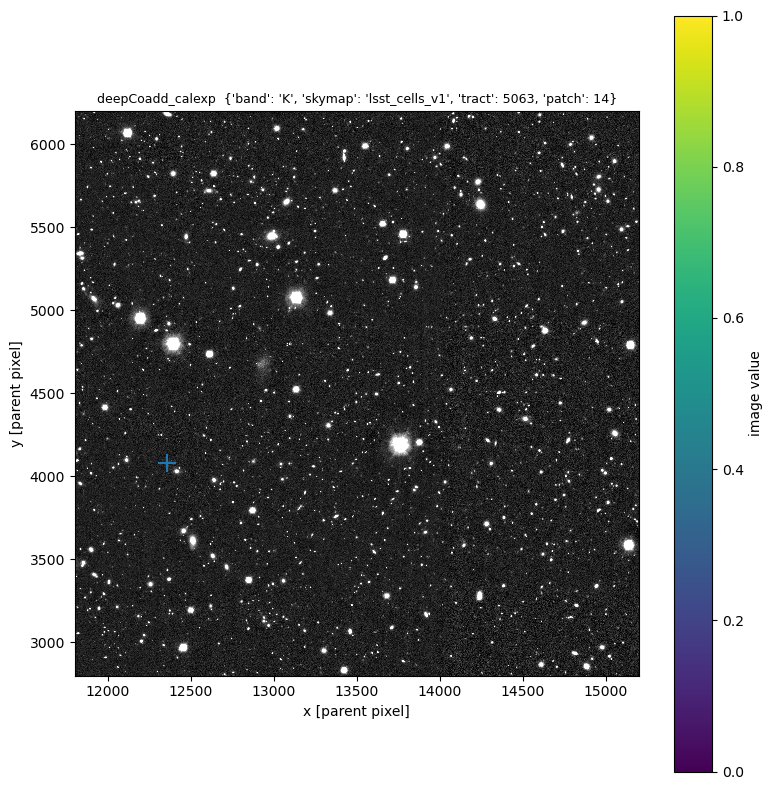

In [14]:
if selected_coadd_ref is None:
    raise RuntimeError("No coadd ref is available.  Run the previous cells from the beginning and inspect the search output.")

coadd = butler.get(selected_coadd_ref)

print("Retrieved:", selected_coadd_ref.datasetType.name)
print("Data ID  :", data_id_to_dict(selected_coadd_ref.dataId))
print("Type     :", type(coadd))

# Extract the science image as a NumPy array.
# ExposureF has coadd.image.array; some similar products may expose the image through maskedImage.
try:
    image_array = np.asarray(coadd.image.array, dtype=float)
except Exception:
    image_array = np.asarray(coadd.maskedImage.image.array, dtype=float)

finite = np.isfinite(image_array)
if not np.any(finite):
    raise RuntimeError("The image array contains no finite pixels.")

vmin, vmax = np.nanpercentile(image_array[finite], [1, 99])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = np.nanmin(image_array[finite]), np.nanmax(image_array[finite])

# Use the Butler bbox as the plotting extent, so the axes are in parent pixel coordinates.
try:
    bbox = coadd.getBBox()
    extent = [bbox.getMinX(), bbox.getMaxX(), bbox.getMinY(), bbox.getMaxY()]
except Exception:
    extent = None

plt.figure(figsize=(8, 8))
plt.imshow(
    image_array,
    origin="lower",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax,
    extent=extent,
    cmap="gray",
)

# Mark the target position if the coadd has a WCS.
try:
    target_pixel = coadd.getWcs().skyToPixel(target_sphere_point)
    plt.scatter([target_pixel.getX()], [target_pixel.getY()], marker="+", s=150)
except Exception as err:
    print("Could not mark the target position:", repr(err))

plt.title(f"{selected_coadd_ref.datasetType.name}  {data_id_to_dict(selected_coadd_ref.dataId)}", fontsize=9)
plt.xlabel("x [parent pixel]")
plt.ylabel("y [parent pixel]")
plt.colorbar(label="image value")
plt.tight_layout()
plt.show()


### 1.12 Find catalogue products

This cell first tries the most likely catalogue dataset types, then prints which ones exist at the selected tract/patch or tract.

In [15]:
PREFERRED_CATALOGUE_DATASET_TYPES = [
    # Tract-level object tables
    "objectTable_tract",
    "objectTable",
    "objectTableCore",

    # Patch-level or coadd source products
    "deepCoadd_forced_src",
    "deepCoadd_meas",
    "deepCoadd_ref",
    "deepCoadd_mergeDet",
    "deepCoadd_deblendedFlux",

    # Table versions that may exist in newer processing outputs
    "forcedSourceTable",
    "forcedSourceTable_tract",
    "sourceTable",
    "sourceTable_tract",
]

available_preferred_catalogues = [
    name for name in PREFERRED_CATALOGUE_DATASET_TYPES
    if dataset_type_exists(name)
]

print("Preferred catalogue dataset types available in this repository:")
for name in available_preferred_catalogues:
    print(" ", name)


def is_likely_science_catalogue_dataset_type(dt):
    """Reject logs/configs/metadata and keep likely source/object catalogues."""
    name = dt.name
    lower_name = name.lower()
    storage = str(dt.storageClass).lower()

    reject_tokens = (
        "_log",
        "_config",
        "_metadata",
        "resourceusage",
        "resource_usage",
        "lookuptable",
        "fgcm",
        "calib",
        "summary",
    )
    if any(token in lower_name for token in reject_tokens):
        return False

    # This introductory notebook is focused on coadd/object catalogues, not DIA products.
    if lower_name.startswith("dia_"):
        return False

    name_tokens = (
        "objecttable",
        "deepcoadd_forced",
        "deepcoadd_meas",
        "deepcoadd_ref",
        "sourcetable",
        "forcedsourcetable",
    )
    storage_tokens = (
        "sourcecatalog",
        "dataframe",
        "arrow",
        "astropy",
        "catalog",
    )

    return (
        any(token in lower_name for token in name_tokens)
        or any(token in storage for token in storage_tokens)
    )


# Add other discovered catalogue-like dataset types, without repeating names.
discovered_catalogue_like_names = []
for dt in all_dataset_types:
    if dt.name in available_preferred_catalogues:
        continue
    if is_likely_science_catalogue_dataset_type(dt):
        discovered_catalogue_like_names.append(dt.name)

catalogue_search_list = available_preferred_catalogues + discovered_catalogue_like_names

print()
print(f"Total likely science catalogue dataset types to test: {len(catalogue_search_list)}")
for name in catalogue_search_list:
    print(" ", name)


Preferred catalogue dataset types available in this repository:
  deepCoadd_forced_src
  deepCoadd_meas

Total likely science catalogue dataset types to test: 2
  deepCoadd_forced_src
  deepCoadd_meas


In [16]:
catalogue_refs_by_type = {}

for dataset_type_name in catalogue_search_list:
    refs = query_product(dataset_type_name, data_id_base, max_refs=50)
    if refs:
        catalogue_refs_by_type[dataset_type_name] = refs

print()
print("Catalogue products found at this target:")
if not catalogue_refs_by_type:
    print("  None found.")
else:
    for dataset_type_name, refs in catalogue_refs_by_type.items():
        dims = sorted(dimensions_of(dataset_type_name))
        print(f"  {dataset_type_name:35s}  nrefs={len(refs):3d}  dims={dims}")



Dataset type: deepCoadd_forced_src
Dimensions  : ['band', 'patch', 'skymap', 'tract']
Query dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14}
Number of refs found: 11
  deepCoadd_forced_src {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
  deepCoadd_forced_src {'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
  deepCoadd_forced_src {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
  deepCoadd_forced_src {'band': 'Y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
  deepCoadd_forced_src {'band': 'Z', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
  deepCoadd_forced_src {'band': 'g', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} r

### 1.13 Retrieve one catalogue product

This cell chooses a useful catalogue product, preferring `objectTable_tract` when available.  Tract-level tables can be large, so this cell prints only basic information and the first few rows when possible.

In [17]:
selected_catalogue_type = None
selected_catalogue_ref = None

for name in PREFERRED_CATALOGUE_DATASET_TYPES:
    if name in catalogue_refs_by_type and catalogue_refs_by_type[name]:
        selected_catalogue_type = name
        selected_catalogue_ref = catalogue_refs_by_type[name][0]
        break

if selected_catalogue_ref is None and catalogue_refs_by_type:
    selected_catalogue_type = next(iter(catalogue_refs_by_type))
    selected_catalogue_ref = catalogue_refs_by_type[selected_catalogue_type][0]

if selected_catalogue_ref is None:
    print("No catalogue product was found to retrieve.")
else:
    print("Selected catalogue:")
    print(" ", selected_catalogue_type, data_id_to_dict(selected_catalogue_ref.dataId), "run=", selected_catalogue_ref.run)

    catalogue = butler.get(selected_catalogue_ref)
    print("Type:", type(catalogue))

    try:
        print("Length:", len(catalogue))
    except Exception:
        pass

    print("Columns/schema names:")
    try:
        print(list(catalogue.columns)[:50])
    except Exception:
        try:
            print(list(catalogue.schema.getNames())[:50])
        except Exception:
            print("Could not list columns/schema names.")

    print()
    print("First rows/records:")
    try:
        display(catalogue.head())
    except Exception:
        try:
            display(catalogue.asAstropy()[:5])
        except Exception:
            try:
                print(catalogue[:5])
            except Exception:
                print(catalogue)


Selected catalogue:
  deepCoadd_forced_src {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 14} run= u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
Type: <class 'lsst.afw.table.SourceCatalog'>
Length: 18150
Columns/schema names:
['ext_convolved_ConvolvedFlux_1_kron_flag_apCorr', 'modelfit_CModel_flag_apCorr', 'ext_convolved_ConvolvedFlux_3_deconv', 'ext_photometryKron_KronFlux_flag_bad_shape_no_psf', 'ext_convolved_ConvolvedFlux_2_3_3_instFluxErr', 'ext_convolved_ConvolvedFlux_3_4_5_flag_apertureTruncated', 'ext_convolved_ConvolvedFlux_3_4_5_apCorrErr', 'base_LocalBackground_instFluxErr', 'ext_convolved_ConvolvedFlux_2_deconv', 'ext_convolved_ConvolvedFlux_0_kron_apCorrErr', 'base_PixelFlags_flag_sensor_edge', 'ext_convolved_ConvolvedFlux_3_kron_apCorrErr', 'base_PixelFlags_flag_badCenterAll', 'modelfit_CModel_exp_flag_badReference', 'ext_convolved_ConvolvedFlux_2_3_3_flag_sincCoeffsTruncated', 'ext_convolved_ConvolvedFlux_1_deconv', 'coord_dec', 'modelfit_CModel_exp_i

id,coord_ra,coord_dec,parent,deblend_nChild,base_SdssCentroid_x,base_SdssCentroid_y,base_SdssCentroid_xErr,base_SdssCentroid_yErr,base_SdssCentroid_flag,base_SdssCentroid_flag_edge,base_SdssCentroid_flag_noSecondDerivative,base_SdssCentroid_flag_almostNoSecondDerivative,base_SdssCentroid_flag_notAtMaximum,base_SdssCentroid_flag_near_edge,base_SdssCentroid_flag_resetToPeak,base_SdssCentroid_flag_badError,base_TransformedCentroid_x,slot_Centroid_x,base_TransformedCentroid_y,slot_Centroid_y,base_TransformedCentroid_flag,base_CircularApertureFlux_flag_badCentroid,base_GaussianFlux_flag_badCentroid,base_InputCount_flag_badCentroid,base_LocalBackground_flag_badCentroid,base_PsfFlux_flag_badCentroid,base_SdssCentroid_flag_badInitialCentroid,base_SdssShape_flag_badCentroid,base_Variance_flag_badCentroid,ext_convolved_ConvolvedFlux_0_flag_badCentroid,ext_convolved_ConvolvedFlux_1_flag_badCentroid,ext_convolved_ConvolvedFlux_2_flag_badCentroid,ext_convolved_ConvolvedFlux_3_flag_badCentroid,ext_convolved_ConvolvedFlux_flag_badCentroid,ext_photometryKron_KronFlux_flag_badInitialCentroid,modelfit_DoubleShapeletPsfApprox_flag_badCentroid,slot_Centroid_flag,base_InputCount_flag,base_InputCount_value,base_InputCount_flag_noInputs,base_SdssShape_xx,base_SdssShape_yy,base_SdssShape_xy,base_SdssShape_xxErr,base_SdssShape_yyErr,base_SdssShape_xyErr,base_SdssShape_x,base_SdssShape_y,base_SdssShape_instFlux,base_SdssShape_instFluxErr,base_SdssShape_psf_xx,slot_PsfShape_xx,base_SdssShape_psf_yy,slot_PsfShape_yy,base_SdssShape_psf_xy,slot_PsfShape_xy,base_SdssShape_instFlux_xx_Cov,base_SdssShape_instFlux_yy_Cov,base_SdssShape_instFlux_xy_Cov,base_SdssShape_flag,base_SdssShape_flag_unweightedBad,base_SdssShape_flag_unweighted,base_SdssShape_flag_shift,base_SdssShape_flag_maxIter,base_SdssShape_flag_psf,base_TransformedShape_xx,slot_Shape_xx,base_TransformedShape_yy,slot_Shape_yy,base_TransformedShape_xy,slot_Shape_xy,base_TransformedShape_flag,base_GaussianFlux_flag_badShape,slot_Shape_flag,modelfit_DoubleShapeletPsfApprox_0_xx,modelfit_DoubleShapeletPsfApprox_0_yy,modelfit_DoubleShapeletPsfApprox_0_xy,modelfit_DoubleShapeletPsfApprox_0_x,modelfit_DoubleShapeletPsfApprox_0_y,modelfit_DoubleShapeletPsfApprox_0_0,modelfit_DoubleShapeletPsfApprox_0_1,modelfit_DoubleShapeletPsfApprox_0_2,modelfit_DoubleShapeletPsfApprox_0_3,modelfit_DoubleShapeletPsfApprox_0_4,modelfit_DoubleShapeletPsfApprox_0_5,modelfit_DoubleShapeletPsfApprox_1_xx,modelfit_DoubleShapeletPsfApprox_1_yy,modelfit_DoubleShapeletPsfApprox_1_xy,modelfit_DoubleShapeletPsfApprox_1_x,modelfit_DoubleShapeletPsfApprox_1_y,modelfit_DoubleShapeletPsfApprox_1_0,modelfit_DoubleShapeletPsfApprox_1_1,modelfit_DoubleShapeletPsfApprox_1_2,modelfit_DoubleShapeletPsfApprox_flag,modelfit_DoubleShapeletPsfApprox_flag_invalidPointForPsf,modelfit_DoubleShapeletPsfApprox_flag_invalidMoments,modelfit_DoubleShapeletPsfApprox_flag_maxIterations,base_CircularApertureFlux_3_0_instFlux,base_CircularApertureFlux_3_0_instFluxErr,base_CircularApertureFlux_3_0_flag,base_CircularApertureFlux_3_0_flag_apertureTruncated,base_CircularApertureFlux_3_0_flag_sincCoeffsTruncated,base_CircularApertureFlux_4_5_instFlux,base_CircularApertureFlux_4_5_instFluxErr,base_CircularApertureFlux_4_5_flag,base_CircularApertureFlux_4_5_flag_apertureTruncated,base_CircularApertureFlux_4_5_flag_sincCoeffsTruncated,base_CircularApertureFlux_6_0_instFlux,base_CircularApertureFlux_6_0_instFluxErr,base_CircularApertureFlux_6_0_flag,base_CircularApertureFlux_6_0_flag_apertureTruncated,base_CircularApertureFlux_6_0_flag_sincCoeffsTruncated,base_CircularApertureFlux_9_0_instFlux,base_CircularApertureFlux_9_0_instFluxErr,base_CircularApertureFlux_9_0_flag,base_CircularApertureFlux_9_0_flag_apertureTruncated,base_CircularApertureFlux_9_0_flag_sincCoeffsTruncated,base_CircularApertureFlux_12_0_instFlux,base_CircularApertureFlux_12_0_instFluxErr,base_CircularApertureFlux_12_0_flag,base_CircularApertureFlux_12_0_flag_apertureTruncated,base_CircularAperture